In [7]:
import random
import numpy as np
import matplotlib.pyplot as plt
import simpy

In [8]:
# Parameter simulasi
RANDOM_SEED = 42
NUM_TELLERS_LIST = [1, 2, 3]  # Daftar jumlah teller untuk diuji (Tugas 1)
ARRIVAL_RATE_NORMAL = 5       # Tingkat kedatangan normal (pelanggan per menit)
ARRIVAL_RATE_PEAK = 10        # Tingkat kedatangan saat jam sibuk (pelanggan per menit) (Tugas 2)
SERVICE_RATE = 7              # Tingkat pelayanan rata-rata (pelanggan per menit)
SIM_TIME = 20                 # Total waktu simulasi dalam menit
VIP_PROBABILITY = 0.3         # Probabilitas pelanggan adalah VIP (Tugas 4)

In [9]:
# Dictionary untuk menyimpan metrik
wait_times_dict = {tellers: [] for tellers in NUM_TELLERS_LIST}  # Waktu tunggu berdasarkan jumlah teller
utilization_dict = {tellers: {'times': [], 'values': []} for tellers in NUM_TELLERS_LIST}  # Utilisasi per jumlah teller
vip_wait_times = []     # Waktu tunggu pelanggan VIP
regular_wait_times = [] # Waktu tunggu pelanggan biasa

In [10]:
class BankQueueSimulation:
    def __init__(self, env, num_tellers, service_rate):
        self.env = env
        self.teller = simpy.PriorityResource(env, num_tellers)
        self.service_rate = service_rate
        self.teller_busy_time = 0
        self.last_event_time = 0

    def serve_customer(self, customer_id):
        start_service = self.env.now
        service_time = random.expovariate(self.service_rate)
        yield self.env.timeout(service_time)
        end_service = self.env.now
        self.teller_busy_time += (end_service - start_service)
        self.last_event_time = end_service
        utilization = self.teller_busy_time / self.env.now if self.env.now > 0 else 0
        utilization_dict[self.teller.capacity]['times'].append(self.env.now)
        utilization_dict[self.teller.capacity]['values'].append(utilization)
        print(f"Pelanggan {customer_id} selesai dilayani pada {self.env.now:.2f} menit.")

In [11]:
def customer_process(env, customer_id, bank, is_vip):
    """Proses pelanggan masuk ke antrian dan dilayani."""
    arrival_time = env.now
    priority = 0 if is_vip else 1  # Prioritas: 0 untuk VIP, 1 untuk biasa
    print(f"Pelanggan {customer_id} {'(VIP)' if is_vip else ''} datang pada {arrival_time:.2f} menit.")

    with bank.teller.request(priority=priority) as request:
        yield request  # Tunggu hingga teller tersedia
        wait_time = env.now - arrival_time  # Hitung waktu tunggu
        if is_vip:
            vip_wait_times.append(wait_time)
        else:
            regular_wait_times.append(wait_time)
        wait_times_dict[bank.teller.capacity].append(wait_time)

        print(f"Pelanggan {customer_id} {'(VIP)' if is_vip else ''} mulai dilayani setelah menunggu {wait_time:.2f} menit.")
        yield env.process(bank.serve_customer(customer_id))

In [12]:
def customer_arrivals(env, bank, arrival_rate_normal, arrival_rate_peak):
    """Proses kedatangan pelanggan dengan interval acak."""
    customer_id = 0
    while True:
        # Simulasi jam sibuk (menit 5-10)
        arrival_rate = arrival_rate_peak if 5 <= env.now <= 10 else arrival_rate_normal
        yield env.timeout(random.expovariate(arrival_rate))  # Interval kedatangan acak
        customer_id += 1
        is_vip = random.random() < VIP_PROBABILITY  # Tentukan apakah pelanggan adalah VIP
        env.process(customer_process(env, customer_id, bank, is_vip))

In [13]:
# Jalankan simulasi untuk setiap jumlah teller
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

for num_tellers in NUM_TELLERS_LIST:
    print(f"\n=== Simulasi dengan {num_tellers} Teller ===")
    env = simpy.Environment()
    bank = BankQueueSimulation(env, num_tellers, SERVICE_RATE)
    env.process(customer_arrivals(env, bank, ARRIVAL_RATE_NORMAL, ARRIVAL_RATE_PEAK))
    env.run(until=SIM_TIME)


=== Simulasi dengan 1 Teller ===
Pelanggan 1 (VIP) datang pada 0.20 menit.
Pelanggan 1 (VIP) mulai dilayani setelah menunggu 0.00 menit.
Pelanggan 1 selesai dilayani pada 0.24 menit.
Pelanggan 2  datang pada 0.27 menit.
Pelanggan 2  mulai dilayani setelah menunggu 0.00 menit.
Pelanggan 3 (VIP) datang pada 0.49 menit.
Pelanggan 2 selesai dilayani pada 0.59 menit.
Pelanggan 3 (VIP) mulai dilayani setelah menunggu 0.09 menit.
Pelanggan 3 selesai dilayani pada 0.59 menit.
Pelanggan 4 (VIP) datang pada 0.60 menit.
Pelanggan 4 (VIP) mulai dilayani setelah menunggu 0.00 menit.
Pelanggan 4 selesai dilayani pada 0.61 menit.
Pelanggan 5 (VIP) datang pada 0.74 menit.
Pelanggan 5 (VIP) mulai dilayani setelah menunggu 0.00 menit.
Pelanggan 5 selesai dilayani pada 0.86 menit.
Pelanggan 6 (VIP) datang pada 0.95 menit.
Pelanggan 6 (VIP) mulai dilayani setelah menunggu 0.00 menit.
Pelanggan 7 (VIP) datang pada 1.13 menit.
Pelanggan 6 selesai dilayani pada 1.19 menit.
Pelanggan 7 (VIP) mulai dilayani s

In [14]:
# Analisis distribusi waktu tunggu (Plot 1)
print("\n=== Analisis Distribusi Waktu Tunggu ===")
for num_tellers in NUM_TELLERS_LIST:
    wait_times = wait_times_dict[num_tellers]
    avg_wait = np.mean(wait_times) if wait_times else 0
    max_wait = np.max(wait_times) if wait_times else 0
    percent_under_1min = (sum(1 for t in wait_times if t < 1) / len(wait_times) * 100) if wait_times else 0
    print(f"Dengan {num_tellers} teller:")
    print(f"  - Rata-rata waktu tunggu: {avg_wait:.2f} menit")
    print(f"  - Waktu tunggu maksimum: {max_wait:.2f} menit")
    print(f"  - Persentase pelanggan yang menunggu < 1 menit: {percent_under_1min:.2f}%")



=== Analisis Distribusi Waktu Tunggu ===
Dengan 1 teller:
  - Rata-rata waktu tunggu: 2.19 menit
  - Waktu tunggu maksimum: 6.84 menit
  - Persentase pelanggan yang menunggu < 1 menit: 55.74%
Dengan 2 teller:
  - Rata-rata waktu tunggu: 0.10 menit
  - Waktu tunggu maksimum: 0.88 menit
  - Persentase pelanggan yang menunggu < 1 menit: 100.00%
Dengan 3 teller:
  - Rata-rata waktu tunggu: 0.02 menit
  - Waktu tunggu maksimum: 0.34 menit
  - Persentase pelanggan yang menunggu < 1 menit: 100.00%


In [15]:
# Analisis utilisasi teller (Plot 2)
print("\n=== Analisis Utilisasi Teller ===")
for num_tellers in NUM_TELLERS_LIST:
    util_times = utilization_dict[num_tellers]['times']
    util_values = utilization_dict[num_tellers]['values']
    avg_util = np.mean(util_values) if util_values else 0
    peak_util = [val for t, val in zip(util_times, util_values) if 5 <= t <= 10]
    max_peak_util = np.max(peak_util) if peak_util else 0
    print(f"Dengan {num_tellers} teller:")
    print(f"  - Rata-rata utilisasi: {avg_util:.2f}")
    print(f"  - Utilisasi maksimum selama jam sibuk (menit 5-10): {max_peak_util:.2f}")


=== Analisis Utilisasi Teller ===
Dengan 1 teller:
  - Rata-rata utilisasi: 0.90
  - Utilisasi maksimum selama jam sibuk (menit 5-10): 0.94
Dengan 2 teller:
  - Rata-rata utilisasi: 0.98
  - Utilisasi maksimum selama jam sibuk (menit 5-10): 1.14
Dengan 3 teller:
  - Rata-rata utilisasi: 0.88
  - Utilisasi maksimum selama jam sibuk (menit 5-10): 1.13


In [16]:
# Analisis waktu tunggu VIP vs Biasa (Plot 3)
print("\n=== Analisis Waktu Tunggu VIP vs Biasa ===")
avg_vip_wait = np.mean(vip_wait_times) if vip_wait_times else 0
max_vip_wait = np.max(vip_wait_times) if vip_wait_times else 0
percent_vip_under_1min = (sum(1 for t in vip_wait_times if t < 1) / len(vip_wait_times) * 100) if vip_wait_times else 0
avg_regular_wait = np.mean(regular_wait_times) if regular_wait_times else 0
max_regular_wait = np.max(regular_wait_times) if regular_wait_times else 0
percent_regular_under_1min = (sum(1 for t in regular_wait_times if t < 1) / len(regular_wait_times) * 100) if regular_wait_times else 0

print("Pelanggan VIP:")
print(f"  - Rata-rata waktu tunggu: {avg_vip_wait:.2f} menit")
print(f"  - Waktu tunggu maksimum: {max_vip_wait:.2f} menit")
print(f"  - Persentase pelanggan yang menunggu < 1 menit: {percent_vip_under_1min:.2f}%")
print("Pelanggan Biasa:")
print(f"  - Rata-rata waktu tunggu: {avg_regular_wait:.2f} menit")
print(f"  - Waktu tunggu maksimum: {max_regular_wait:.2f} menit")
print(f"  - Persentase pelanggan yang menunggu < 1 menit: {percent_regular_under_1min:.2f}%")


=== Analisis Waktu Tunggu VIP vs Biasa ===
Pelanggan VIP:
  - Rata-rata waktu tunggu: 0.10 menit
  - Waktu tunggu maksimum: 0.99 menit
  - Persentase pelanggan yang menunggu < 1 menit: 100.00%
Pelanggan Biasa:
  - Rata-rata waktu tunggu: 0.98 menit
  - Waktu tunggu maksimum: 6.84 menit
  - Persentase pelanggan yang menunggu < 1 menit: 80.71%


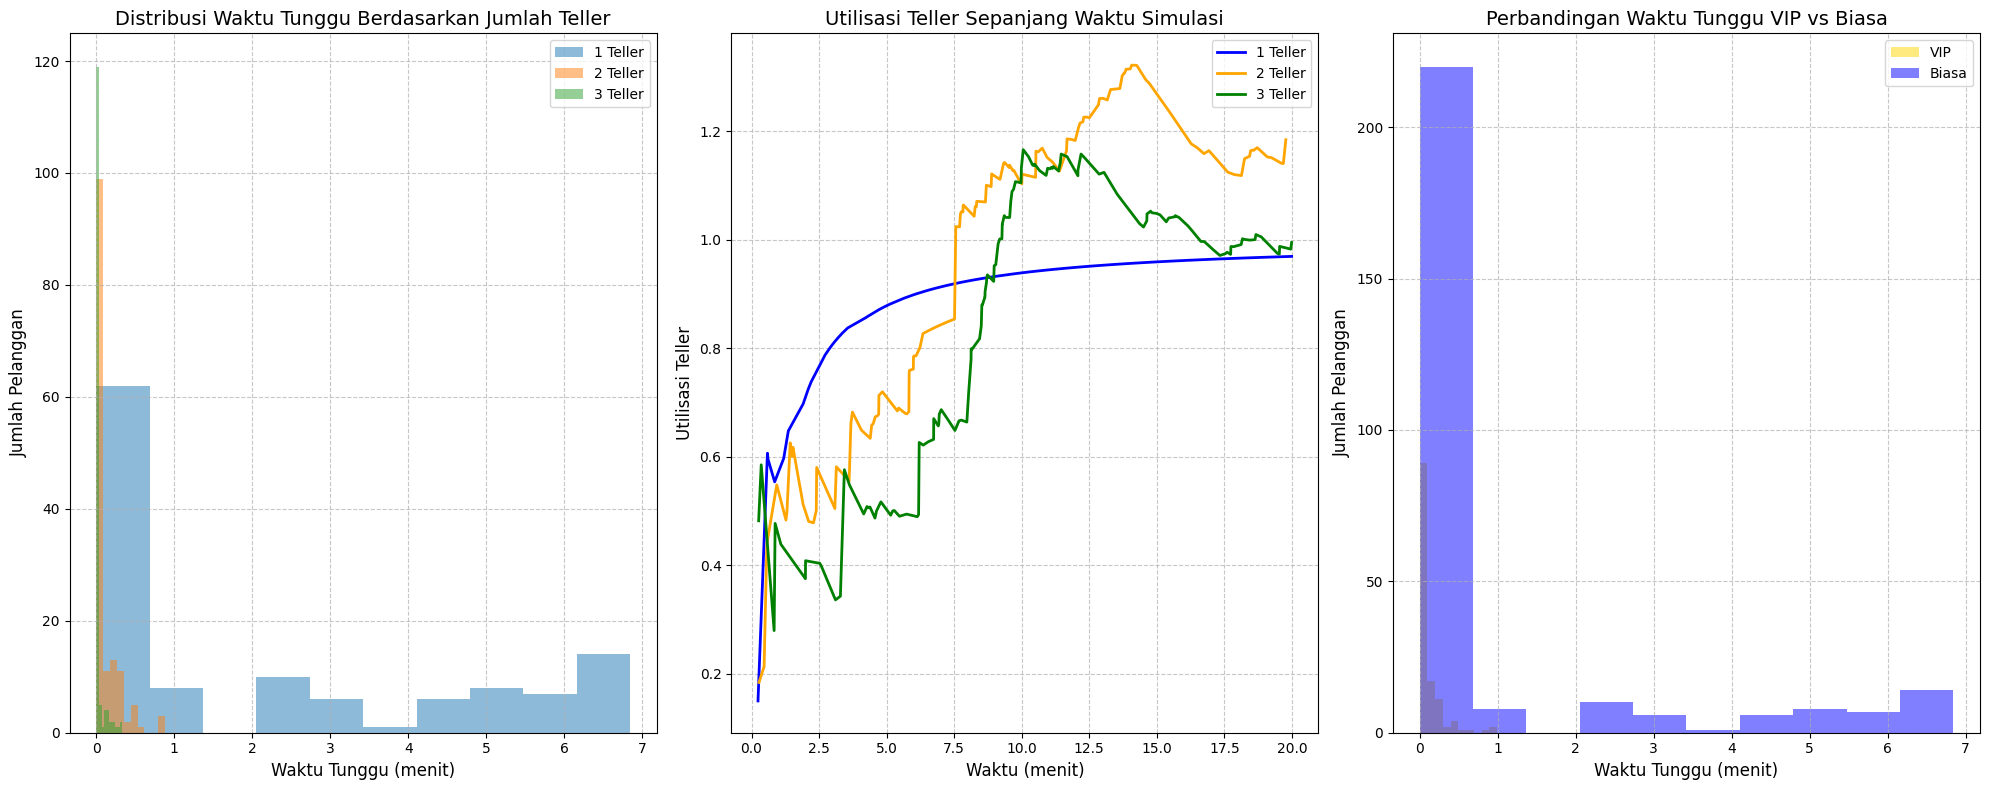

In [17]:
# Visualisasi hasil
plt.figure(figsize=(20, 8))

# Plot 1: Distribusi waktu tunggu
plt.subplot(1, 3, 1)
for num_tellers in NUM_TELLERS_LIST:
    plt.hist(wait_times_dict[num_tellers], bins=10, alpha=0.5, label=f"{num_tellers} Teller")
plt.xlabel("Waktu Tunggu (menit)", fontsize=12)
plt.ylabel("Jumlah Pelanggan", fontsize=12)
plt.title("Distribusi Waktu Tunggu Berdasarkan Jumlah Teller", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Utilisasi teller
plt.subplot(1, 3, 2)
colors = {1: 'blue', 2: 'orange', 3: 'green'}
for num_tellers in NUM_TELLERS_LIST:
    plt.plot(
        utilization_dict[num_tellers]['times'],
        utilization_dict[num_tellers]['values'],
        color=colors[num_tellers],
        label=f"{num_tellers} Teller",
        linewidth=2
    )
plt.xlabel("Waktu (menit)", fontsize=12)
plt.ylabel("Utilisasi Teller", fontsize=12)
plt.title("Utilisasi Teller Sepanjang Waktu Simulasi", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 3: Perbandingan waktu tunggu VIP vs Biasa
plt.subplot(1, 3, 3)
plt.hist(vip_wait_times, bins=10, alpha=0.5, label="VIP", color="gold")
plt.hist(regular_wait_times, bins=10, alpha=0.5, label="Biasa", color="blue")
plt.xlabel("Waktu Tunggu (menit)", fontsize=12)
plt.ylabel("Jumlah Pelanggan", fontsize=12)
plt.title("Perbandingan Waktu Tunggu VIP vs Biasa", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()